In [1]:
#image import for processing

from PIL import Image
import numpy as np
from IPython.display import display

def import_for_pillow(path):
    img = Image.open(path)

    print(f"✅ Loaded successfully")
    print(f"   Format: {img.format}")
    print(f"   Size: {img.size}")  
    print(f"   Mode: {img.mode}")  

    if img.mode != 'RGB':
        img = img.convert('RGB')

    img_array = np.array(img)

    return img, img_array

pil_img, array = import_for_pillow("./bees/samples_south/EAoR1r1m_ind01.dw.png")
# display(pil_img)

✅ Loaded successfully
   Format: PNG
   Size: (2048, 1536)
   Mode: RGB


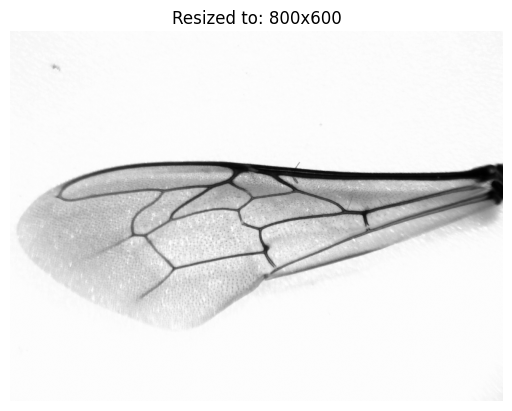

In [2]:
# Grayscaling and downsizing the image 
import cv2

def smart_resize_grayscale(img, max_dimension=800):
    
    # Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Smart Resize
    height, width = gray.shape
    scale = min(max_dimension / height, max_dimension / width)
    
    # Calculate new dimensions (rounded to nearest integer)
    new_width = int(width * scale)
    new_height = int(height * scale)

    # Use INTER_LANCZOS4 for best detail preservation when downsizing
    # INTER_AREA is also good for shrinking images significantly
    resized = cv2.resize(gray, (new_width, new_height), interpolation=cv2.INTER_LANCZOS4)

    return resized

# Usage
image_gray = smart_resize_grayscale(array, max_dimension=800)

# Display to verify
import matplotlib.pyplot as plt
plt.imshow(image_gray, cmap='gray')
plt.axis('off')
plt.title(f"Resized to: {image_gray.shape[1]}x{image_gray.shape[0]}")
plt.show()

In [ ]:
filtered = cv2.medianBlur(noisy_image, 5)

In [ ]:
blur1 = cv2.GaussianBlur(img, (0, 0), sigma1=5)
blur2 = cv2.GaussianBlur(img, (0, 0), sigma1=10)

# Calculate Difference of Gaussians
dog = cv2.subtract(blur1, blur2)

# Optional: Take absolute value to capture both edges and dark/bright transitions
dog_abs = cv2.convertScaleAbs(dog)

# Apply thresholding to get binary edge map
# Use Otsu's thresholding for automatic cutoff or a fixed value
_, thresh = cv2.threshold(dog_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)